# `v72_fig1b_p38`

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS

model = "EGFR_MAPK__logobs"
data = "dream_cytof"
filename = "evaluate_all_figure1b"

df = pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0)

In [2]:
val_df = df[(df.dataset == "val") & (df.ref == "DMM")]
val_df.features.fillna("None", inplace=True)

# Exclude multimodal best_RFE
val_df = val_df[val_df.features != "best_RFE_10_permute"]

In [3]:
val_df.groupby(["context", "features", "multiheaded", "n_hidden", "depth", "dropout_rate", "l1reg_inflater_output", "l2reg_inflater_output", "recon_loss"]).rmse.mean()

context          features           multiheaded  n_hidden  depth  dropout_rate  l1reg_inflater_output  l2reg_inflater_output  recon_loss
cytof_init       RFE_15_permute     False        1.0       0.0    0.10          0.01                   0.0                    0.0001        0.605612
                                                 2.0       0.0    0.00          0.01                   0.0                    0.0001        0.608058
                                                                  0.02          0.01                   0.0                    0.0001        0.578174
                                                                  0.05          0.01                   0.0                    0.0001        0.578208
                                                                  0.10          0.01                   0.0                    0.0001        0.584546
                                                                  0.15          0.01                   0.0            

# n_hidden (fixed depth=0)

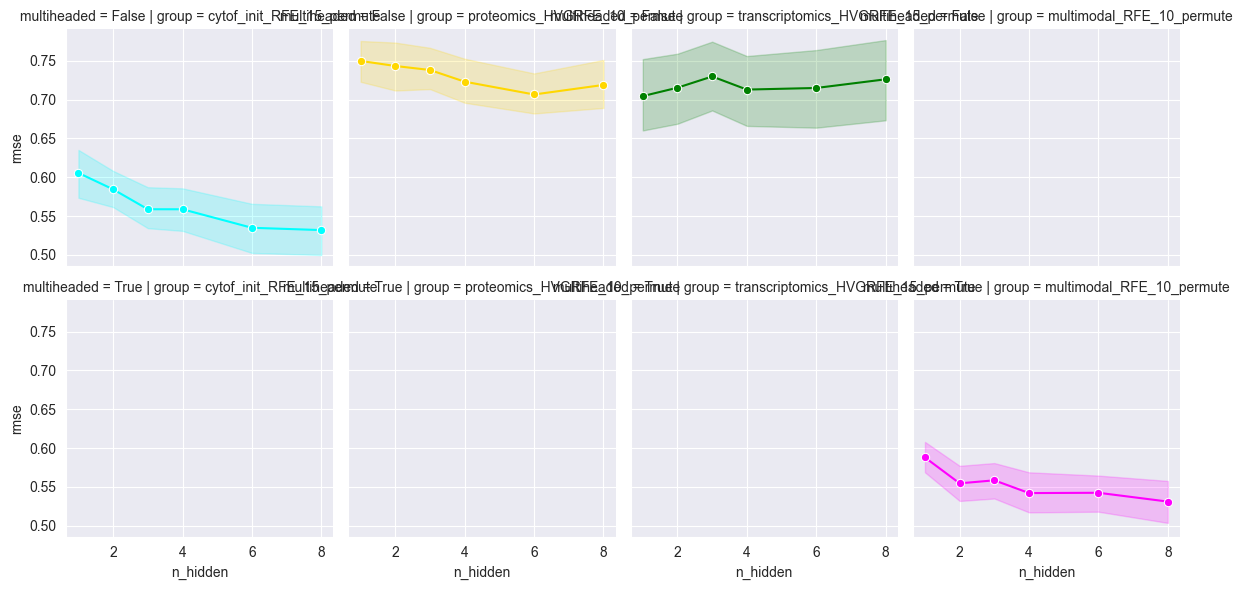

In [4]:
val_df["group"] = val_df["context"] + "_" + val_df["features"]

palette = {
    "cytof_init_RFE_15_permute": "cyan",
    "proteomics_HVGRFE_10_permute": "gold",
    "transcriptomics_HVGRFE_15_permute": "green",
    "multimodal_RFE_10_permute": "magenta",
    # "multimodal_best_RFE_10_permute": "purple"
}

g = sns.FacetGrid(
    val_df[(val_df.depth == 0) & (val_df.dropout_rate == 0.1) & (val_df.l2reg_inflater_output == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.recon_loss == 1e-4)],
    row="multiheaded",
    col="group",
    col_order=palette.keys()
)

g.map_dataframe(
    sns.lineplot,
    x="n_hidden",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [5]:
from scipy import stats

def kruskal_wallis_groups(df, target_metric, group_metric, context_metric="context"):
    for context in df[context_metric].unique():
        context_data = df[df[context_metric] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context/Group: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

In [7]:
kruskal_wallis_groups(
    val_df[(val_df.depth == 0) & (val_df.dropout_rate == 0.1) & (val_df.l2reg_inflater_output == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.recon_loss == 1e-4)],
    "rmse",
    "n_hidden",
    "group"
)

Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=11.55, p-value=0.0415, significant? True
Context/Group: cytof_init_RFE_15_permute - Kruskal-Wallis H-test: H-statistic=16.52, p-value=0.0055, significant? True
Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=7.51, p-value=0.1857, significant? False
Context/Group: transcriptomics_HVGRFE_15_permute - Kruskal-Wallis H-test: H-statistic=0.96, p-value=0.9660, significant? False


# Dropout Rate (`dropout_rate`)

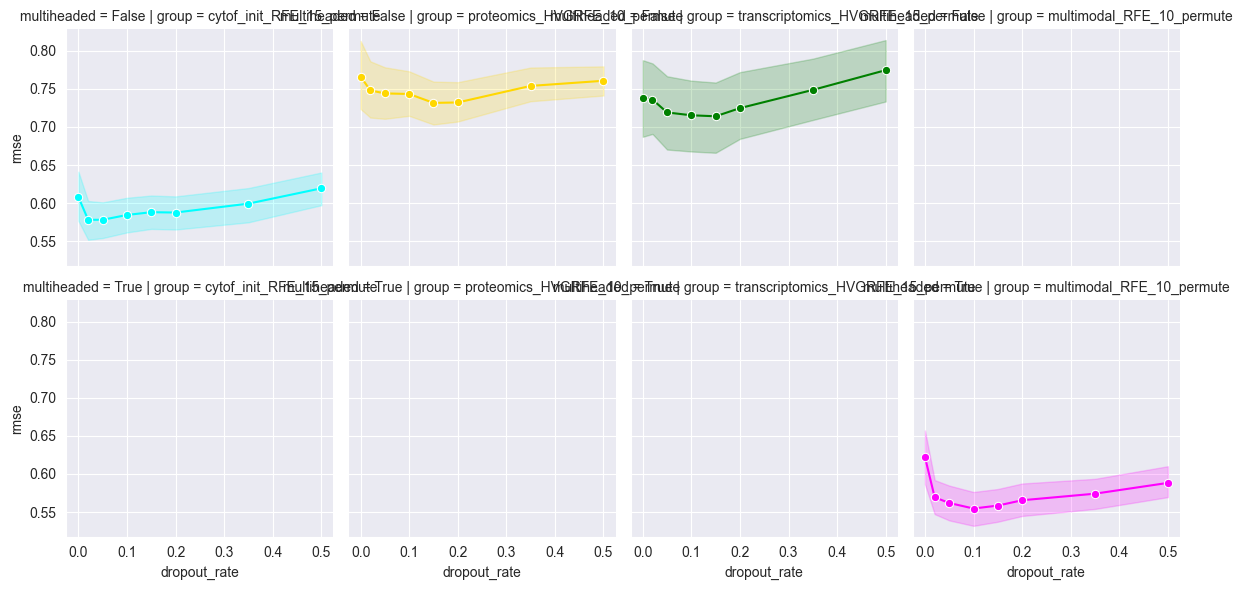

In [10]:
g = sns.FacetGrid(
    val_df[(val_df.n_hidden == 2) & (val_df.depth == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.l2reg_inflater_output == 0) & (val_df.recon_loss == 1e-4)],
    row="multiheaded",
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="dropout_rate",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [11]:
kruskal_wallis_groups(
    val_df[(val_df.n_hidden == 2) & (val_df.depth == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.l2reg_inflater_output == 0) & (val_df.recon_loss == 1e-4)],
    "rmse",
    "dropout_rate",
    "group"
)

Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=15.72, p-value=0.0278, significant? True
Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=5.39, p-value=0.6121, significant? False
Context/Group: transcriptomics_HVGRFE_15_permute - Kruskal-Wallis H-test: H-statistic=6.15, p-value=0.5227, significant? False
Context/Group: cytof_init_RFE_15_permute - Kruskal-Wallis H-test: H-statistic=6.94, p-value=0.4353, significant? False
